In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy

import json
import os
import pickle
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

from daart_utils.session_ids.ibl import NEW_SESS_IDS as new_vids
from daart_utils.session_ids.ibl import SESS_IDS_TEST as test_vids

In [56]:
def get_results(base, mod, v, vids):
    preds = []
    for vid in vids:
        #print(vid)
        #print(base.format(mod, v, vid))
        p = np.load(base.format(mod, v, vid))[:100000]
        #print('p', p.shape)
        p = p.argmax(axis=1)
        preds += list(p)
    preds = np.array(preds)
    return preds

def get_f1_dict(suffix='states'):
    mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_' + suffix + '.npy'
    f1_meta = {}
    #mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']

    for mod in model_list:
        f1_meta[mod] = []
        for v in range(5):
            preds = get_results(mod_base, mod,v)
            f1 = f1_score(states[states>0], preds[states>0], average=None)
            f1_meta[mod].append([np.mean(f1)] + list(f1))
            
    # aggregate results
    f1_plot = {}
    for mod in model_list:
        mean_list = []
        sd_list = []
        for p in range(len(labels)):
            mean = np.mean([a[p] for a in f1_meta[mod]])
            sd = np.std([a[p] for a in f1_meta[mod]])/5
            mean_list.append(mean)
            sd_list.append(sd)
        f1_plot[mod] = (mean_list, sd_list)
        
    return f1_plot

    
def plot_f1(f1_plot, it='regular markers'):
    # Numbers of pairs of bars you want
    N = len(label_names)
    # Position of bars on x-axis
    ind = np.arange(N)

    colors = ['black', 'grey', 'lightgrey', 'slategrey', 'peru', 'brown']
    # Figure size
    plt.figure(figsize=(8,5))

    # Width of a bar 
    width = 0.15     
    i=0
    for mod, (mean, sd) in f1_plot.items():
        if i==0:
            print(mean)
        # Plotting
        label = mod
        if mod == 'nope':
            label='none'
        plt.bar(ind + width*i, mean, width, label=label, color=colors[i],yerr=sd)
        plt.xlabel('classes')
        plt.ylabel('F1 score')
        plt.title('F1 scores with different transforms ({})'.format(it))
        plt.xticks(ind + width, label_names)
        i+=1

    # Finding the best position for legends and putting it
    plt.legend(loc='best')
    plt.show()


def get_stds(suffix='states', labeled_only=True, vids=test_vids, new=False):
    all_res = []
    for mod in model_list:

        for v in range(5):
            res = get_results(mod_base, mod, v, vids)
            if labeled_only and (not new):
                res = res[states > 0]
            elif labeled_only and new:
                res = res[states_new > 0]
            res = np.eye(5, dtype=np.int32)[res]
            all_res.append(res)
        
    all_res = np.array(all_res)
    stds = all_res.std(axis=0) # should be N by n_classes
    stds = np.mean(stds, axis=1)

    return stds
        
def make_df(suffix='states', labeled_only=True, vids=test_vids, new=False):
    if new:
        states_temp = states_new
    else:
        states_temp = states
        

    if labeled_only:
        gt = states_temp[states_temp > 0]
    else:
        gt = states_temp
    
    df_std = []
    ind_count = 0
    stds = get_stds(suffix, labeled_only, vids, new=new)
    for mod in model_list:
        all_res = []
        print(mod)
        
        # Collect results for each fold
        for v in range(5):
            res = get_results(mod_base, mod, v, vids)
            if labeled_only:
                res = res[states_temp > 0]
            all_res.append(res)
        
        # Convert all_res to a numpy array for vectorized operations
        all_res = np.array(all_res)
        print('all_res',all_res.shape)
        
        # Calculate predictions and statistics
        modes = stats.mode(all_res, axis=0).mode[0]
        corrects = (gt == modes).astype(int)
        
        # Construct the DataFrame in one go
        rows = {
            'model': [mod] * len(gt),
            'gt_action': gt,
            'prediction': modes,
            'correct': corrects,
            'std': stds,
            'dtype': [suffix] * len(gt)
        }
        df_std.append(pd.DataFrame(rows, index=np.arange(ind_count, ind_count + len(gt))))
        ind_count += len(gt)
        #df_std = pd.concat(df_std, ignore_index=True)
        
        for m in range(all_res.shape[0]):
            corrects = (gt==all_res[m])
            # Construct the DataFrame in one go
            rows = {
                'model': [f"mod_{m}"] * len(gt),
                'gt_action': gt,
                'prediction': all_res[m],
                'correct': corrects,
                'std': stds,
                'dtype': [suffix] * len(gt)
            }
            df_std.append(pd.DataFrame(rows, index=np.arange(ind_count, ind_count + len(gt))))
            ind_count += len(gt)
        df_std = pd.concat(df_std, ignore_index=True)
    
    
    return df_std    


def make_graph_df(df_std):
    # make df to graph
    models=['nope', 'mod_0', 'mod_1', 'mod_2', 'mod_3', 'mod_4']
    std_vals = np.arange(0, 1, 0.01)
    n_points_dict = {m: np.nan * np.zeros_like(std_vals) for m in models}
    df_line2 = []
    for s, std in enumerate(std_vals):
        #print(std)
        df_tmp_ = df_std[df_std['std'] > std]
        for model_name in models:
            d = df_tmp_[df_tmp_.model == model_name]
            n_points = np.sum(~d['correct'].isna())
            n_points_dict[model_name][s] = n_points
            index = []
            rng = 0
            for row, k in zip(d.index, range(len(d))):
                index.append(f'{row}' + f'_{model_name}_{s}_{k}_{rng}')
            accuarcy = d['correct'].to_numpy()
            df_line2.append(pd.DataFrame({
                'ens-std': std,
                'model': model_name,
                'accuracy': accuarcy,
                'n_points': n_points,
            }, index=index))
    df_line2 = pd.concat(df_line2)
    return df_line2

def make_graph(ax, df_line2):
    # graph df
    #fig, ax = plt.subplots(1, 1, figsize=(10, 6))  # Increase the figure size
    models=['nope', 'mod_0', 'mod_1', 'mod_2', 'mod_3', 'mod_4']
    g = sns.lineplot(
        x='ens-std',
        y='accuracy',
        hue='model',
        hue_order=models,
        #palette=palette,
        data=df_line2,
        ax=ax,
        errorbar='se'
    )
    labels_fontsize=12
    handles, labels = ax.get_legend_handles_labels()
    legend_labels = {
        'nope': 'no transforms ens',
        'all': 'all transforms',
    }
    #ax.set_xlim((0,2))
    ax.legend(
        handles=handles,
        labels=[legend_labels.get(label, label) for label in labels],
        loc='upper left',
        bbox_to_anchor=(1, 1),
        fontsize=labels_fontsize,
        title='model',
        title_fontsize=labels_fontsize
    )

    ax.set_title(suffix)
    return ax

In [57]:

def graph_etho_img(fig, states, markers, sds, start=0,length=600, n_classes=4, buffer=50, vid_id=0):
    n_rows = 4+5+5
    outer_grid = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=fig)
    inner_grid = outer_grid[0].subgridspec(n_rows, 1, hspace=.1, height_ratios=[.2,  .2,.2,.2,.2,.2,.2,  .2,.2,.2,.2,.2,  .4,  .7])
    axes = inner_grid.subplots()  
    vid = test_vids[vid_id]
    
    # graph gt
    gt = pd.read_csv(gt_base.format(vid),index_col=0).to_numpy().argmax(axis=1)
    data = gt[start:(start+length)]
    #print('data', data.shape)
    graph_states(axes[0], data, n_classes,cmap=cmap2)
    axes[0].set(ylabel="labels")
    axes[0].yaxis.label.set(rotation='horizontal', ha='right')
    
    for i in range(5): 
        # load data
        data = np.load(p_base.format(i,vid))
        data = data[start:(start+length)]
        
        # graph model preds
        graph_states(axes[i+1], data.argmax(axis=1), n_classes,cmap=cmap)
        axes[i+1].set(ylabel="Model {}".format(i))
        axes[i+1].yaxis.label.set(rotation='horizontal', ha='right')
        
        # graph entropies
        ent_data = entropy(data, axis=1)
        graph_entropies(axes[i+6], ent_data, i)
        
        # formatting
        axes[i+1].yaxis.label.set(rotation='horizontal', ha='right')
        axes[i+6].yaxis.label.set(rotation='horizontal', ha='right')
    
    # graph ens predictions
    data = states[start:(start+length)]
    graph_states(axes[-3], data, n_classes,cmap=cmap)
    axes[-3].set(ylabel="Ens")
    axes[-3].yaxis.label.set(rotation='horizontal', ha='right')
    unique, counts = np.unique(data, return_counts=True)
    #print(np.asarray((unique, counts)).T)
    
    for ax in axes:
        ax.axvline(x=buffer, color='purple', linestyle='--', linewidth=3)
        ax.axvline(x=length-buffer, color='purple', linestyle='--', linewidth=3)
    
    # graph ens-std
    sds = sds[start:(start+length)]
    #print('sds',sds.shape)
    graph_sds(axes[-2], sds)
    
    # graph markers
    markers = markers[start:(start+length)]
    #print('markers',markers.shape)
    marker_names = ['paw_x', 'paw_y', 'wheel_vel']
    m_inds = range(3)
    graph_markers(axes[-1], markers, marker_names, m_inds)   

def graph_entropies(ax, ents, name=0):
    # plot markers
    spc = .5 * abs(ents.max())
    ax.plot(np.array(range(len(ents))) , ents, color='grey', linewidth=2)
    ax.set_xlim([0, len(ents) - 1])
    ax.set_xticks([])
    ax.spines[['right','left', 'top']].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('ent mod {}'.format(name))
    
    
def graph_states(ax, states, n_classes, cmap=[]):
    n_frames = states.shape[0]
    im = ax.imshow(
        states[None, :], aspect='auto', 
        cmap=cmap, interpolation='none',
        vmin=1, vmax=n_classes)
    ax.set_xlim((0,len(states)))
    ax.set_xticks([])
    ax.set_yticks([])
    
def graph_markers(ax, markers, marker_names, m_inds):
    # plot markers
    spc =  1.8 * abs(markers.max())
    for n in range(len(m_inds)):
        m_tmp = markers[:, m_inds[n]]
        #print('m_tmp',m_tmp.shape)
        ax.plot(np.array(range(len(m_tmp))) , m_tmp + spc*n, color='k', linewidth=2)
        
    ax.set_xlim([0, len(m_tmp) - 1])
    #ax.set_xticks([0,200,400,600,800,1000])
    ax.spines[['right','left', 'top']].set_visible(False)
    ax.set_yticks(spc * np.arange(len(m_inds)))
    ax.set_yticklabels(marker_names)
    ax.set_xlim((0,len(m_tmp)))
    
    
def graph_sds(ax, sds):
    # plot markers
    spc = .5 * abs(sds.max())
    ax.plot(np.array(range(len(sds))) , sds, color='brown', linewidth=2)
        
    ax.set_xlim([0, len(sds) - 1])
    ax.set_xticks([])
    ax.spines[['right','left', 'top']].set_visible(False)
    ax.set_yticks([0,.4, .8])
    ax.set_ylabel('std')
    ax.yaxis.label.set(rotation='horizontal', ha='right')


    

In [58]:
# load gt labels


label_names = ['avg', 'still', 'move', 'wheel_turn', 'groom']

base = '/home/bsb2144/daart_utils/data/ibl/labels-hand/{}_labels.csv'
labels = {}
states = []
for vid in test_vids:
    labs = pd.read_csv(base.format(vid),index_col=0).to_numpy()
    labs = labs.argmax(axis=1)
    states += list(labs)
    labels[vid] = labs
states = np.array(states)

labels_new = {}
states_new = []
for vid in new_vids:
    labs = pd.read_csv(base.format(vid),index_col=0).to_numpy()
    labs = labs.argmax(axis=1)
    states_new += list(labs)
    labels_new[vid] = labs
states_new = np.array(states_new)

## Graph model vs F1 for each session and ens

nope
all_res (5, 37073)


,model,gt_action,prediction,correct,std,dtype
0,nope,1,1,1,0.0,fpv-new
1,nope,1,1,1,0.0,fpv-new
2,nope,1,1,1,0.0,fpv-new
3,nope,1,1,1,0.0,fpv-new
4,nope,1,1,1,0.0,fpv-new


{'mod_0': 0.7357242228337793, 'mod_1': 0.761867127669212, 'mod_2': 0.7592061181459591, 'mod_3': 0.736376295981571, 'mod_4': 0.7406940290572654, 'ens': 0.7553128763542211}


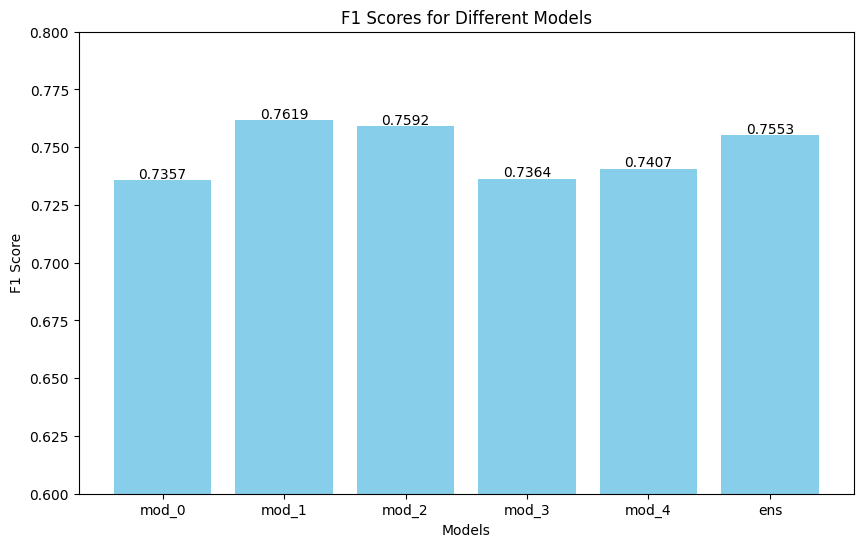

In [59]:
vids=new_vids
new = True
model_list = ['nope']
suffix='fpv-new'#'states'
input_type = 'features-posvel'

mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_'+ input_type + '/version_{}/{}_' + suffix + '.npy'
# old test data
df_std = make_df(suffix=suffix,labeled_only=True, vids=vids,new=new)
display(df_std.head())

f1_mods = ['mod_0', 'mod_1', 'mod_2', 'mod_3', 'mod_4', 'nope',]
f1_dict = {}

for mod in f1_mods:
    y_true = df_std[df_std['model']==mod]['gt_action']
    y_pred = df_std[df_std['model']==mod]['prediction']
    f1_temp = f1_score(y_true, y_pred, average='macro')
    if mod!= 'nope':
        f1_dict[mod] = f1_temp
    else:
        f1_dict['ens'] = f1_temp
    
print(f1_dict)

# Creating the bar plot with enhanced differences
plt.figure(figsize=(10, 6))
bars = plt.bar(f1_dict.keys(), f1_dict.values(), color='skyblue')

# Adding title and labels
plt.title('F1 Scores for Different Models')
plt.xlabel('Models')
plt.ylabel('F1 Score')
# Adding value labels on top of the bars to highlight the differences
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height - 0.0005, 
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Adjust y-axis limit to make differences more noticeable
plt.ylim(0.6, 0.8)

# Display the plot
plt.show()


In [60]:
# new videos

## Graph confidence vs accuracy by quantile of std

In [67]:
# make df with cols
# model_name | gt_action | prediction | correct (0/1) | SD | dtype
#suffix: states | markers-new | markers-smooth | fpv-smooth | fpv-new
model_list = ['nope']#, 'all', 'rotate', 'shift', 'gauss', 'shot']
suffix= 'fpv-new'#'states'
#input_type = 'markers'
input_type = 'features-posvel'
new=True
vids = new_vids
mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_'+ input_type + '/version_{}/{}_' + suffix + '.npy'

In [68]:
df_std = make_df(suffix=suffix,labeled_only=True,new=new,vids=vids)
df_line2 = make_graph_df(df_std)

nope
all_res (5, 37073)


In [69]:
# graph bar plot of sds
# suffix='fpv-smooth'
# #input_type = 'markers'
# input_type = 'features-posvel'
# mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_'+ input_type + '/version_{}/{}_' + suffix + '.npy'
std_vals = np.arange(0, 1, 0.01)
stds = get_stds(suffix='states', labeled_only=True,new=new,vids=vids)

y_vals = []
for val in std_vals:
    n_points = stds[stds>val].shape[0]
    y_vals.append(n_points)

[10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 10492, 8097, 5822, 5822, 5822, 1088, 1088, 1088, 1088, 1088, 1088, 462, 462, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


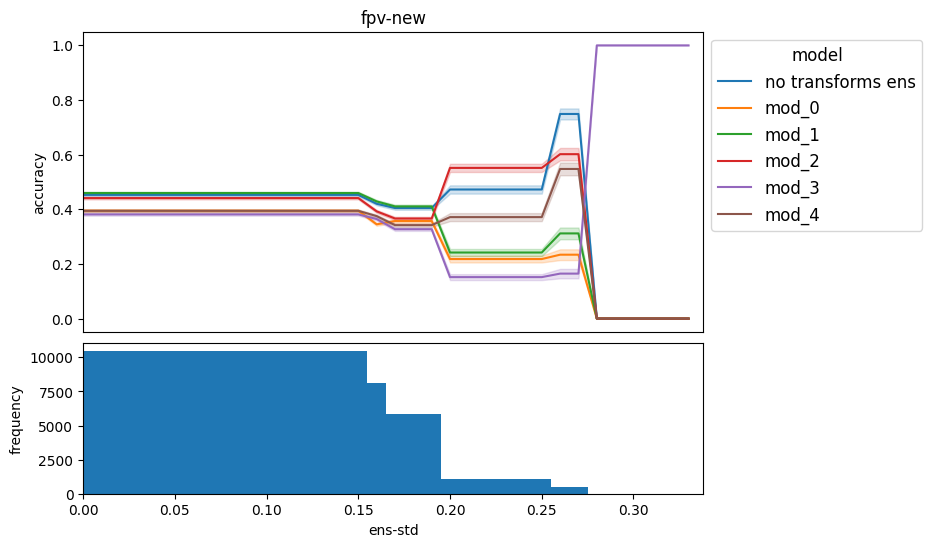

In [70]:
n_cols = 1
n_rows = 2

fig_width = 8
fig_height = 6

fig = plt.figure(figsize=(fig_width, fig_height))
outer_grid = fig.add_gridspec(1, 1)
inner_grid = [outer_grid[0].subgridspec(n_rows, n_cols, hspace=.05, height_ratios=[1,.5])]

axes = inner_grid[0].subplots()
make_graph(axes[0], df_line2)
axes[0].set_xlim(0,np.max(stds))
axes[0].set_xticks([])
axes[0].set_xlabel('')

width=.01
axes[1].bar(std_vals, y_vals, label=std_vals, width=width)
axes[1].set_xlim(0,np.max(stds))
axes[1].set_ylabel('frequency')
axes[1].set_xlabel('ens-std')
print(y_vals)

# 5: 0.0
# 4+1: 0.16
# 3+2: 0.196
# 3+1+1: 0.258
# 2+2+1: 0.276
# 2+1+1: 0.338 (unlikely)
# 1+1+1+1+1: 0.4

## Graph ens-std vs model entropy

In [9]:
def get_ents(vids, v, base, mod='nope'):
    ents = []
    for vid in vids:
        p = np.load(base.format(mod, v, vid))[:100000]
        ent = entropy(p, axis=1)
        ents += list(ent)
    ents = np.array(ents)
    return ents

    
def get_df_ent(df, vids, base):
    ents = [0 for _ in range(2000000)]
    for i in range(5): 
        ent = get_ents(vids, i, base)
        ents += list(ent)
    ents=np.array(ents)
    df["entropy"] = ents

        

In [10]:
# graph high std vs traces
model_list = ['nope']
suffix='fpv-new'
new=True
if new:
    vids = new_vids
else:
    vids = test_vids
    
input_type = 'features-posvel'
mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_'+ input_type + '/version_{}/{}_' + suffix + '.npy'
df_std3 = make_df(suffix,labeled_only=False,vids=vids,new=new)


nope
all_res (5, 2000000)


In [11]:
print(df_std3.shape)
#display(df_std3)
get_df_ent(df_std3, vids, mod_base)
display(df_std3)

(12000000, 6)


,model,gt_action,prediction,correct,std,dtype,entropy
0,nope,0,1,0,0.0,fpv-new,0.000000
1,nope,0,1,0,0.0,fpv-new,0.000000
2,nope,0,1,0,0.0,fpv-new,0.000000
3,nope,0,1,0,0.0,fpv-new,0.000000
4,nope,0,1,0,0.0,fpv-new,0.000000
...,...,...,...,...,...,...,...
11999995,mod_4,0,1,0,0.0,fpv-new,0.016751
11999996,mod_4,0,1,0,0.0,fpv-new,0.014967
11999997,mod_4,0,1,0,0.0,fpv-new,0.012974
11999998,mod_4,0,1,0,0.0,fpv-new,0.014675


In [23]:
# remove border frames
# 3 on each side of border

# Find where transitions occur
transition_indices = df_std3.index[df_std3['prediction'].diff().ne(0)].tolist()

# Add indices 3 rows before and after each transition
rows_to_remove = set()
for idx in transition_indices:
    rows_to_remove.update(range(max(0, idx - 3), min(len(df_std3), idx + 4)))

# Remove the rows
df_cleaned = df_std3.drop(rows_to_remove).reset_index(drop=True)

display(df_cleaned)

,model,gt_action,prediction,correct,std,dtype,entropy,std_rounded
0,nope,0,1,0,0.0,fpv-new,0.000000,0.0
1,nope,0,1,0,0.0,fpv-new,0.000000,0.0
2,nope,0,1,0,0.0,fpv-new,0.000000,0.0
3,nope,0,1,0,0.0,fpv-new,0.000000,0.0
4,nope,0,1,0,0.0,fpv-new,0.000000,0.0
...,...,...,...,...,...,...,...,...
10017516,mod_4,0,1,0,0.0,fpv-new,0.016751,0.0
10017517,mod_4,0,1,0,0.0,fpv-new,0.014967,0.0
10017518,mod_4,0,1,0,0.0,fpv-new,0.012974,0.0
10017519,mod_4,0,1,0,0.0,fpv-new,0.014675,0.0


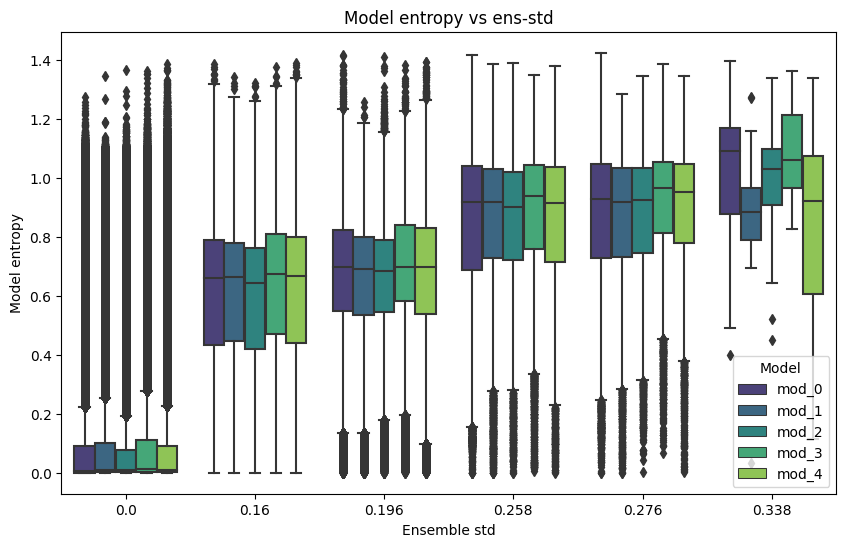

In [26]:
# df_cleaned['std_rounded'] = df_cleaned['std'].round(3)
# plt.figure(figsize=(10, 6))
# sns.boxplot(
#     data=df_cleaned[df_cleaned['model']!='nope'], #[df_std3['std']>0]
#     x='std_rounded', 
#     y='entropy', 
#     hue='model', 
#     palette='viridis',  # You can change this to any palette you like
#     #s=10  # Size of the points
# )

df_std3['std_rounded'] = df_std3['std'].round(3)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_std3[df_std3['model']!='nope'], #[df_std3['std']>0]
    x='std_rounded', 
    y='entropy', 
    hue='model', 
    palette='viridis',  # You can change this to any palette you like
    #s=10  # Size of the points
)

plt.title('Model entropy vs ens-std')
plt.xlabel('Ensemble std')
plt.ylabel('Model entropy')
plt.legend(title='Model',loc='lower right')
plt.show()

## Graph ethograms of high std segments

In [13]:
# graph high std vs traces
model_list = ['nope']
suffix='fpv-new'
new=True
if new:
    vids = new_vids
else:
    vids = test_vids
    
input_type = 'features-posvel'
mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_'+ input_type + '/version_{}/{}_' + suffix + '.npy'
df_std2 = make_df(suffix,labeled_only=False,vids=vids,new=True)


nope
all_res (5, 2000000)


In [14]:
# each vid has 100,000 frames
# 5 test videos
n_vids=5
n_frames=100000
df_reg = df_std2[df_std2['model']=='nope']
df_pstd = df_reg#[df_reg['std']!=0]
df_pstd['vid_id'] = (df_pstd.index // n_frames)
df_pstd['frame_id'] = (df_pstd.index) - (df_pstd['vid_id'] * n_frames)
df_pstd['vid_name'] = [vids[i] for i in df_pstd['vid_id']]
df_pstd=df_pstd.reset_index()

/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [15]:
df_sd = df_reg[df_reg['std']!=0]
df_sd['vid_id'] = (df_sd.index // n_frames)
df_sd['frame_id'] = (df_sd.index) - (df_sd['vid_id'] * n_frames)
df_sd['vid_name'] = [vids[i] for i in df_sd['vid_id']]
df_sd=df_sd.reset_index()
print(df_sd.shape)
display(df_sd)
#df_pstd.to_csv('results/std_df.csv')

(217666, 10)


/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

,index,model,gt_action,prediction,correct,std,dtype,vid_id,frame_id,vid_name
0,299,nope,0,1,0,0.160000,fpv-new,0,299,1b715600-0cbc-442c-bd00-5b0ac2865de1
1,314,nope,0,1,0,0.195959,fpv-new,0,314,1b715600-0cbc-442c-bd00-5b0ac2865de1
2,436,nope,0,1,0,0.160000,fpv-new,0,436,1b715600-0cbc-442c-bd00-5b0ac2865de1
3,437,nope,0,1,0,0.160000,fpv-new,0,437,1b715600-0cbc-442c-bd00-5b0ac2865de1
4,438,nope,0,2,0,0.160000,fpv-new,0,438,1b715600-0cbc-442c-bd00-5b0ac2865de1
...,...,...,...,...,...,...,...,...,...,...
217661,1999966,nope,0,2,0,0.195959,fpv-new,19,99966,f115196e-8dfe-4d2a-8af3-8206d93c1729
217662,1999967,nope,0,2,0,0.195959,fpv-new,19,99967,f115196e-8dfe-4d2a-8af3-8206d93c1729
217663,1999968,nope,0,2,0,0.160000,fpv-new,19,99968,f115196e-8dfe-4d2a-8af3-8206d93c1729
217664,1999969,nope,0,2,0,0.160000,fpv-new,19,99969,f115196e-8dfe-4d2a-8af3-8206d93c1729


In [16]:
def extract_state_runs(states, min_length=10):
    state_snippets = []
    buffer = 10  # number of frames removed at beg/end of session 
    i_beg = buffer
    curr_state = states[i_beg]
    curr_len = 1
    temp = []
    for i in range(i_beg + 1, len(states) - buffer):
        next_state = states[i]
        if next_state == curr_state+1:
            temp.append(next_state)    
        else:
            if len(temp) >= min_length:
                state_snippets.append(temp)
            temp = [next_state]
        curr_state = next_state
    
    return state_snippets

In [17]:
runs = extract_state_runs(list(df_sd['frame_id']), min_length=30)
print(len(runs))


295


In [18]:
def graph_etho_img2(fig, states, markers, sds, chunks, n_classes=4, buffer=50, vid_id=0):
    n_rows = 4+5+5
    outer_grid = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=fig)
    inner_grid = outer_grid[0].subgridspec(n_rows, 1, hspace=.1, height_ratios=[.2,  .2,.2,.2,.2,.2,.2,  .2,.2,.2,.2,.2,  .4,  .7])
    axes = inner_grid.subplots()  
    #vid = test_vids[vid_id]
    vid = new_vids[vid_id]
    
    # graph gt
    gt = pd.read_csv(gt_base.format(vid),index_col=0).to_numpy().argmax(axis=1)
    data = []
    for start, length in chunks:
        data += list(gt[start:(start+length)])
    data = np.array(data)
    
    #print('data', data.shape)
    graph_states(axes[0], data, n_classes,cmap=cmap2)
    axes[0].set(ylabel="labels")
    axes[0].yaxis.label.set(rotation='horizontal', ha='right')
    
    for i in range(5): 
        # load data
        data_all = np.load(p_base.format(i,vid))
        data = []
        for start, length in chunks:
            data += list(data_all[start:(start+length)])
        data = np.array(data)
        
        # graph model preds
        graph_states(axes[i+1], data.argmax(axis=1), n_classes,cmap=cmap)
        axes[i+1].set(ylabel="Model {}".format(i))
        axes[i+1].yaxis.label.set(rotation='horizontal', ha='right')
        
        # graph entropies
        ent_data = entropy(data, axis=1)
        graph_entropies(axes[i+6], ent_data, i)
        
        # formatting
        axes[i+1].yaxis.label.set(rotation='horizontal', ha='right')
        axes[i+6].yaxis.label.set(rotation='horizontal', ha='right')
    
    # graph ens predictions
    data = []
    for start, length in chunks:
        data += list(states[start:(start+length)])
    data = np.array(data)
    
    graph_states(axes[-3], data, n_classes,cmap=cmap)
    axes[-3].set(ylabel="Ens")
    axes[-3].yaxis.label.set(rotation='horizontal', ha='right')
    unique, counts = np.unique(data, return_counts=True)
    #print(np.asarray((unique, counts)).T)
        
    
    # graph ens-std
    sds_new = []
    for start, length in chunks:
        sds_new += list(sds[start:(start+length)])
    sds_new = np.array(sds_new)
    graph_sds(axes[-2], sds_new)
    
    # graph markers
    markers_new = []
    for start, length in chunks:
        markers_new += list(markers[start:(start+length)])
    markers_new = np.array(markers_new)
    marker_names = ['paw_x', 'paw_y', 'wheel_vel']
    m_inds = range(3)
    graph_markers(axes[-1], markers_new, marker_names, m_inds)  
    
    # graph lines around high sd chunks
    for ax in axes:
        #ax.axvline(x=buffer, color='purple', linestyle='--', linewidth=3)
        #ax.axvline(x=length-buffer, color='purple', linestyle='--', linewidth=3)
        
        # graph lines between chunks
        place = 0
        for chunk in chunks[:-1]:
            place += chunk[1]
            ax.axvline(x=place, color='purple', linestyle='--', linewidth=3)


7
8
13
6
19
21
15
16
15
29
8
36
6
24
18
7
9
13
19
6


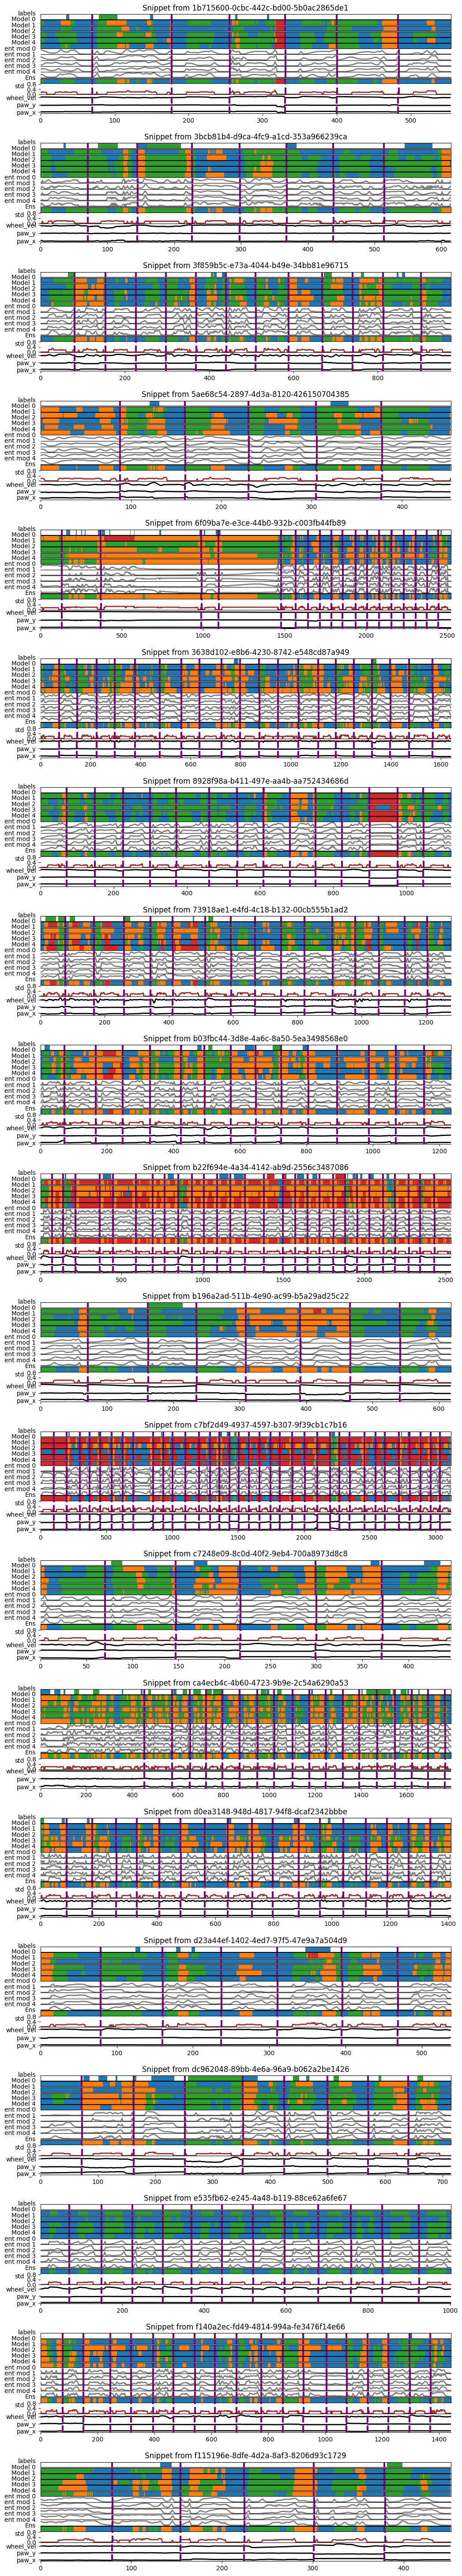

In [19]:
# graph keypoints vs ens-sd for ens-sd > 0
m_base = "/home/bsb2144/daart_utils/data/ibl/fpv-new/{}_labeled.csv"
p_base = "/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/nope-5-good_sample-0_"+input_type+"/version_{}/{}_fpv-new.npy"#states.npy"
gt_base = "/home/bsb2144/daart_utils/data/ibl/labels-hand/{}_labels.csv"


n_cols = 1
n_rows = 20

fig_width = 12
fig_height = 25 *3

fig = plt.figure(figsize=(fig_width, fig_height))
outer_grid = fig.add_gridspec(n_rows, 1, hspace=0.3)
inner_grid = [outer_grid[r].subgridspec(1, n_cols, hspace=.3) for r in range(n_rows)]
buffer=20
colors = plt.cm.tab10.colors[:4]
cmap = ListedColormap(colors, 'indexed')
colors2 = ['white']+ list(plt.cm.tab10.colors[:4])
cmap2 = ListedColormap(colors2, 'indexed')
for r in range(20):#range(n_rows): 
    #vid = test_vids[r]
    vid = new_vids[r]
    axes = inner_grid[r].subplots()
    
    #markers = np.load(m_base.format(vid))
    markers = pd.read_csv(m_base.format(vid), index_col=0).to_numpy()
    sds = df_pstd[df_pstd['vid_name']==vid]['std']
    preds = df_pstd[df_pstd['vid_name']==vid]['prediction']
    runs = extract_state_runs(list(df_sd[df_sd['vid_name']==vid]['frame_id']), min_length=30)
    print(len(runs))
    # chunk_id = 1
    # chunk_start = runs[chunk_id][0]
    # chunk_len = len(runs[chunk_id])
    # start = chunk_start-buffer
    # length = chunk_len+(2*buffer)
    
    chunks = []
    for chunk in runs:
        chunk_start = chunk[0]
        chunk_len = len(chunk)
        start = chunk_start-buffer
        length = chunk_len+(2*buffer)
        chunks.append((start, length))

    
    # graph etho
    #graph_etho_img(axes, preds, markers, sds, start=start, length=length, buffer=buffer, vid_id=r)
    graph_etho_img2(axes, preds, markers, sds, chunks, buffer=buffer, vid_id=r)
    axes.axis('off')
    axes.set_title("Snippet from {}".format(vid))


    